# 🤖 Ćwiczenie: zbuduj własnego agenta-analityka sprzedaży

Masz surowy eksport sprzedaży (`sales_dataset.csv`, 20 000 transakcji z lat 2023–2024). Zbudujesz agenta, który sam wybiera narzędzia, analizuje dane i na koniec przygotowuje raport z rekomendacjami.

**Nie piszesz kodu pandas** — funkcje, które czyszczą dane i liczą wyniki, są gotowe. Twoja praca to to, co naprawdę decyduje o jakości agenta: **opisy narzędzi, instrukcje (prompt systemowy) i dobre pytania**.

| Etap | Co robisz |
|---|---|
| 0 | Konfiguracja: plik z danymi i klucz API |
| 1a | Poznajesz surowe dane i szukasz w nich problemów |
| 🔔 | Spotkanie 1 |
| 1b | Czyścisz dane i sprawdzasz, czy czyszczenie zadziałało |
| 🔔 | Spotkanie 2 |
| 2 | Opisujesz narzędzia, piszesz prompt i zadajesz pytania kontrolne |
| 🔔 | Spotkanie 3 |
| 3 | Dajesz agentowi notatnik (`insights.md`) |
| 🔔 | Spotkanie 4 |
| 4 | Zadanie finałowe: raport dla zarządu + weryfikacja liczb |
| 🔔 | Spotkanie końcowe |

Miejsca do uzupełnienia są oznaczone jako **`TODO`**.

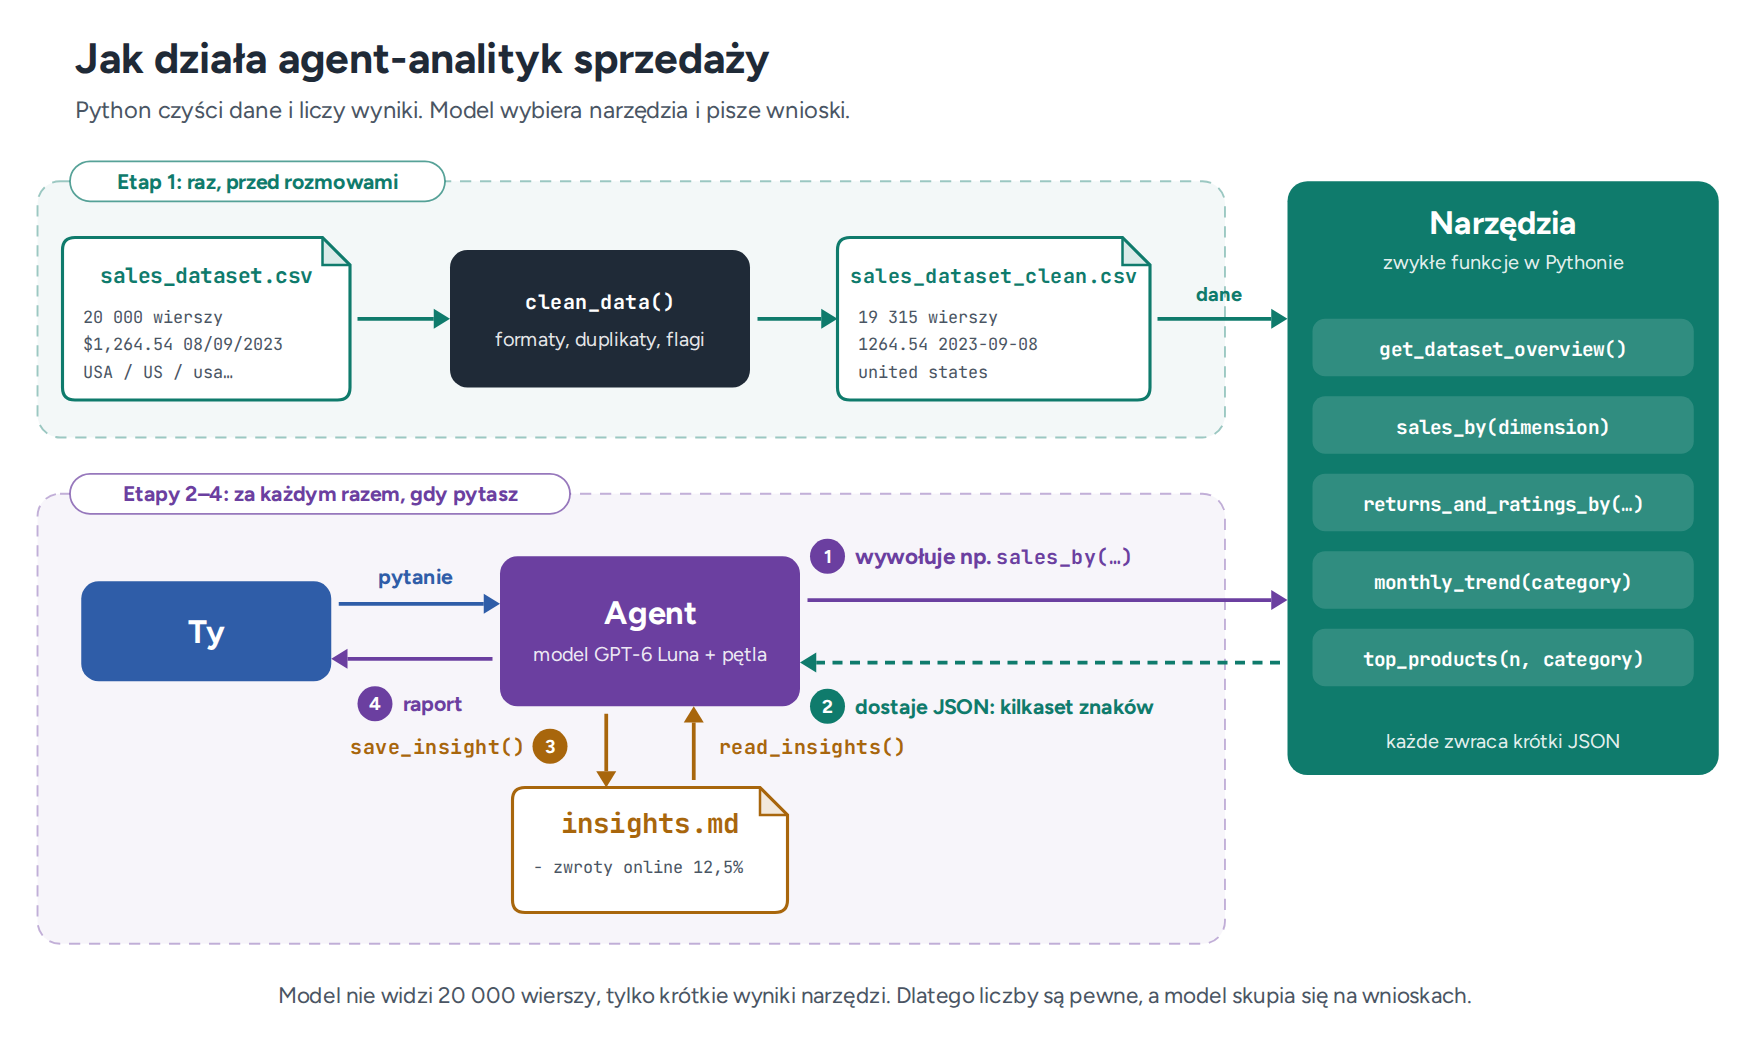

## Etap 0 — Konfiguracja (5 min)

1. Kliknij ikonkę folderu 📁 po lewej stronie i przeciągnij tam plik **`sales_dataset.csv`**.
2. Uruchom dwie komórki poniżej. Druga zapyta o Twój klucz API OpenAI (wklej go i naciśnij Enter).
3. Uruchom też trzecią komórkę (pomocnicze funkcje warsztatu).

💡 **Uruchamiaj komórki po kolei** (`Shift + Enter`). Jeśli klikniesz „Uruchom wszystko”, notebook sam zatrzyma się na końcu bieżącego etapu — dalej idziemy razem, po spotkaniu w grupie.

In [ ]:
!pip install openai reportlab python-pptx -q

In [ ]:
import os
from getpass import getpass
from openai import OpenAI

client = OpenAI(api_key=getpass("Paste your OpenAI API key: "))
MODEL = "gpt-6-luna"

if os.path.exists("/content/sales_dataset.csv"):
    print("✅ Everything ready: API key set, sales_dataset.csv found.")
else:
    print("❌ sales_dataset.csv not found. Upload it with the folder icon on the left.")

In [ ]:
# @title Pomocnicze funkcje warsztatu (nie musisz ich czytać)
class StopExecution(Exception):
    """Stops 'Run all' at the end of a stage, without an ugly error message."""
    def _render_traceback_(self):
        return []


def stop_here(stage, meeting):
    print(f"✋ Koniec etapu {stage}. Czas na {meeting} — pytania są poniżej.")
    print("Po spotkaniu przejdź do następnego etapu i uruchamiaj komórki po kolei (Shift + Enter).")
    raise StopExecution


def check_todos():
    """The agent does not start until the TODOs from Etap 2 are done."""
    missing = []
    if "YOUR PROMPT" in SYSTEM_PROMPT or "TODO" in SYSTEM_PROMPT or not SYSTEM_PROMPT.strip():
        missing.append("SYSTEM_PROMPT (Etap 2b): napisz, kim jest agent i jak ma pracować")
    for tool in TOOLS:
        if "TODO" in tool["function"]["description"]:
            missing.append(f"opis narzędzia {tool['function']['name']} (Etap 2a)")
    if missing:
        print("🛑 Agent nie wystartuje, dopóki nie uzupełnisz:")
        for item in missing:
            print("   •", item)
        print("Po poprawkach uruchom ponownie komórki z Etapów 2a i 2b.")
        raise StopExecution


def check_insight_tools():
    if "save_insight" not in TOOL_FUNCTIONS:
        print("🛑 Agent nie ma jeszcze notatnika: odkomentuj 4 linijki w komórce z INSIGHT_TOOLS (Etap 3) i ją uruchom.")
        raise StopExecution

print("✅ Workshop helpers ready.")

## Etap 1a — Poznaj surowe dane (10 min)

Zanim cokolwiek policzy agent, zobaczmy, jak wyglądają surowe dane w pliku CSV. Otwórz też sam plik: kliknij dwukrotnie `sales_dataset.csv` w panelu plików po lewej.

**Zadanie:**
1. Przejrzyj kolumny i kilka pierwszych wierszy. Co opisuje jeden wiersz?
2. Wypisz **problemy z danymi**, które widzisz (formaty, pisownia, braki, dziwne wartości…). Pomogą Ci komórki poniżej i mini-checklista z cheatsheetu pandas.
3. Zastanów się, **na jakie pytania biznesowe** te dane mogą odpowiedzieć, a na jakie nie.

In [ ]:
import pandas as pd

raw = pd.read_csv("sales_dataset.csv", dtype=str, keep_default_na=False, encoding="utf-8-sig")
print("Rows, columns:", raw.shape)
print(list(raw.columns))
raw.head()

In [ ]:
# How many different spellings? Change the column name to check others: order_status, category, customer_country, return_flag...
raw["payment_method"].value_counts()

In [ ]:
print("Duplicated transaction_id:", raw["transaction_id"].duplicated().sum())

# A random sample of dates and amounts: how many different formats can you spot?
raw[["order_date", "unit_price", "total_amount", "quantity", "return_flag"]].sample(10, random_state=7)

In [ ]:
# Your own check — use the cheatsheet (e.g. raw["customer_country"].value_counts())

In [ ]:
# ✋ This cell intentionally stops "Run all" at the end of the stage
stop_here("1a", "Spotkanie 1")

### 🔔 Spotkanie 1

- Jakie problemy z danymi znaleźliście? Zbierzmy wspólną listę.
- Które z nich najbardziej zafałszowałyby wyniki, gdyby agent liczył na surowych danych?
- Na jakie pytania biznesowe te dane mogą odpowiedzieć? A na jakie nie (np. czego w nich brakuje)?

## Etap 1b — Czyszczenie danych i jego kontrola (10 min)

Uruchomimy gotową funkcję `clean_data()`. Zapisze ona oczyszczone dane do nowego pliku **`sales_dataset_clean.csv`**. Twoje zadanie to sprawdzić, **czy czyszczenie zadziałało dobrze** — tak, jak sprawdzałbyś/sprawdzałabyś pracę agenta albo współpracownika.

Na spotkaniu odpowiemy na te pytania, więc miej je w głowie od początku:

### 🔔 Spotkanie 2 — pytania

- Popatrz na `sales_dataset_clean.csv` — czy wszystkie problemy z danymi zostały rozwiązane?
- Ile wariantów metody płatności było przed czyszczeniem, a ile jest po?
- Ile duplikatów usunięto i ile wierszy oznaczono jako podejrzane?
- Która decyzja z tabeli niżej wydaje Ci się najbardziej dyskusyjna? Czy agent AI powinien podejmować takie decyzje sam?

### Co robi `clean_data()`

Nie musisz czytać kodu funkcji (kliknij, jeśli jesteś ciekawa/ciekawy), ważne są **decyzje**, które podejmuje:

| Problem | Decyzja |
|---|---|
| Kwoty w różnych formatach (`$1,264.54`, `1 264,54`, `582.61 USD`) | zamiana na jedną liczbę |
| Daty w 6 formatach | jeden format (RRRR-MM-DD); dwuznaczne daty (`08/09/2023`) rozstrzygane datą dostawy (dostawa jest zawsze 1–14 dni po zamówieniu) |
| Wielkie/małe litery i spacje w kategoriach | jedna pisownia na wartość; `returned item` = `returned` |
| Kraj (`USA`, `US`, `united states`…) i waluta (`$`, `USD`) | jedna wartość |
| `return_flag`: `NO`, `no`, `0`, `YES`, `1`, `yes` | True / False |
| Duplikaty `transaction_id` | zostaje pierwsza kopia |
| Ujemne ceny, ilość > 100 | **oznaczone** w kolumnie `flagged` (nie usunięte) i pominięte w analizie |
| Przychód | nowa kolumna `net_revenue` = cena × ilość × (1 − rabat), bez wysyłki i podatku; zamówienia anulowane nie wchodzą do przychodu |

In [ ]:
# @title Gotowa funkcja clean_data() (kliknij, żeby zobaczyć kod)
import re
import json
import numpy as np
import pandas as pd

DATA_FILE = "sales_dataset.csv"


# =============================================================================
# CLEANING — ready-made, you don't need to change anything here
# =============================================================================

def _to_number(value):
    """'$1,264.54', '1 264,54', '582.61 USD', '9,99' -> float. Empty -> NaN."""
    s = str(value).replace("$", "").replace("USD", "").replace(" ", "").replace("\u00a0", "").strip()
    if s == "":
        return np.nan
    if "," in s and "." in s:      # 1,264.54 -> comma is a thousands separator
        s = s.replace(",", "")
    elif "," in s:                 # 1264,54 -> comma is the decimal separator
        s = s.replace(",", ".")
    return float(s)


def _date_candidates(value):
    """All possible readings of a date string (2 readings for ambiguous 08/09/2023)."""
    s = str(value).strip()
    if s == "":
        return []
    m = re.fullmatch(r"(\d{4})-(\d{2})-(\d{2})(?: \d{2}:\d{2}:\d{2})?", s)          # 2024-03-05
    if m:
        return [pd.Timestamp(int(m[1]), int(m[2]), int(m[3]))]
    m = re.fullmatch(r"(\d{2})\.(\d{2})\.(\d{4})", s)                               # 05.03.2024
    if m:
        return [pd.Timestamp(int(m[3]), int(m[2]), int(m[1]))]
    m = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4})", s)                                 # 05/03/2024 or 03/05/2024
    if m:
        a, b, y = int(m[1]), int(m[2]), int(m[3])
        out = []
        if b <= 12:
            out.append(pd.Timestamp(y, b, a))   # DD/MM/YYYY
        if a <= 12 and a != b:
            out.append(pd.Timestamp(y, a, b))   # MM/DD/YYYY
        return out
    try:
        return [pd.to_datetime(s, format="%B %d, %Y")]                               # March 05, 2024
    except ValueError:
        return []


def _resolve_order_date(order_value, delivery_value):
    """Pick the order-date reading that is 1-14 days before delivery (that's the gap in this data)."""
    orders, deliveries = _date_candidates(order_value), _date_candidates(delivery_value)
    if len(orders) == 1:
        return orders[0], False
    if len(orders) == 0:
        return pd.NaT, False
    fitting = {o for o in orders for d in deliveries if 1 <= (d - o).days <= 14}
    if len(fitting) == 1:
        return fitting.pop(), False
    return pd.NaT, True      # still ambiguous -> no month for this row


def _clean_text(series):
    return series.str.strip().str.replace(r"\s+", " ", regex=True).str.lower()


def clean_data(path=DATA_FILE):
    """Load the raw export, clean it and return (clean_df, report)."""
    raw = pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig")
    df = raw.copy()
    report = {"raw_rows": len(raw)}

    # 1. Money columns -> numbers
    for col in ["unit_price", "shipping_cost", "total_amount"]:
        df[col] = df[col].map(_to_number)
    df["quantity"] = pd.to_numeric(df["quantity"])
    df["discount_percent"] = pd.to_numeric(df["discount_percent"].replace("", np.nan))
    df["customer_rating"] = pd.to_numeric(df["customer_rating"].replace("", np.nan))

    # 2. Dates -> one format; ambiguous ones resolved with the delivery date
    resolved = [_resolve_order_date(o, d) for o, d in zip(df["order_date"], df["delivery_date"])]
    ambiguous = [len(_date_candidates(o)) > 1 for o in df["order_date"]]
    df["order_date"] = pd.to_datetime([r[0] for r in resolved])
    df["date_uncertain"] = [r[1] for r in resolved]
    df["date_was_ambiguous"] = ambiguous
    df["month"] = df["order_date"].dt.to_period("M").astype(str).replace("NaT", np.nan)

    def _delivery(order_date, value):
        options = _date_candidates(value)
        if len(options) == 1:
            return options[0]
        fitting = [d for d in options if pd.notna(order_date) and 1 <= (d - order_date).days <= 14]
        return fitting[0] if len(fitting) == 1 else pd.NaT
    df["delivery_date"] = pd.to_datetime([_delivery(o, d) for o, d in zip(df["order_date"], df["delivery_date"])])

    # 3. Text categories -> one spelling per value
    for col in ["category", "sales_channel", "region", "payment_method", "order_status"]:
        df[col] = _clean_text(df[col]).replace("", np.nan)
    df["order_status"] = df["order_status"].replace({"returned item": "returned"})
    df["customer_country"] = "united states"   # all 6 variants mean the same country
    df["currency"] = "USD"                     # '$', 'USD', 'usd', 'USD ' all mean the same
    df["return_flag"] = _clean_text(df["return_flag"]).map({"yes": True, "1": True, "no": False, "0": False})

    # 4. Duplicates: same transaction_id = the same order (copies differ only in formatting)
    before = len(df)
    df = df.drop_duplicates(subset="transaction_id", keep="first")
    report["duplicates_removed"] = before - len(df)

    # 5. Invalid rows -> flagged, not deleted
    df["flagged"] = (df["unit_price"] < 0) | (df["quantity"] > 100)
    report["flagged_rows"] = int(df["flagged"].sum())

    # 6. Net revenue = price x quantity x (1 - discount); fallback: total_amount - shipping
    from_parts = df["unit_price"] * df["quantity"] * (1 - df["discount_percent"] / 100)
    from_total = df["total_amount"] - df["shipping_cost"]
    df["net_revenue"] = from_parts.fillna(from_total).round(2)

    report["clean_rows"] = len(df)
    report["ambiguous_dates_resolved_with_delivery_date"] = int((df["date_was_ambiguous"] & ~df["date_uncertain"]).sum())
    report["ambiguous_dates_unresolved"] = int(df["date_uncertain"].sum())
    report["rows_without_month"] = int(df["month"].isna().sum())
    report["rows_without_revenue"] = int(df["net_revenue"].isna().sum())
    return df, report

In [ ]:
SALES, CLEANING_REPORT = clean_data()
SALES.to_csv("sales_dataset_clean.csv", index=False)

for key, value in CLEANING_REPORT.items():
    print(f"{key:48} {value}")
print("\n✅ Saved: sales_dataset_clean.csv (open it from the file panel on the left)")

### Sprawdź, czy czyszczenie zadziałało

Wczytujemy **nowy plik** i patrzymy na te same kolumny co w Etapie 1a. Zmieniaj nazwy kolumn i sprawdzaj kolejne problemy z Waszej listy ze Spotkania 1.

In [ ]:
clean = pd.read_csv("sales_dataset_clean.csv")
print("Rows, columns:", clean.shape)
clean.head()

In [ ]:
# Same check as before — change the column name: order_status, category, customer_country, return_flag...
clean["payment_method"].value_counts()

In [ ]:
print("Duplicated transaction_id:", clean["transaction_id"].duplicated().sum())
print("\nMissing values per column:")
clean.isna().sum()

In [ ]:
# Rows flagged as suspicious — what is wrong with them?
clean[clean["flagged"]][["transaction_id", "unit_price", "quantity", "total_amount"]].head(10)

In [ ]:
# Your own check — use the cheatsheet

In [ ]:
# ✋ This cell intentionally stops "Run all" at the end of the stage
stop_here("1b", "Spotkanie 2")

### 🔔 Spotkanie 2

Wróćcie do pytań z początku Etapu 1b. Co udało się naprawić, a co zostało w danych?

## Etap 2 — Narzędzia, prompt i pytania kontrolne (10 min)

Agent dostaje 5 gotowych narzędzi. Każde zwraca **krótkie, policzone już podsumowanie**, a nie 20 000 wierszy — model nie musi (i nie powinien) niczego liczyć sam.

| Narzędzie | Co zwraca |
|---|---|
| `get_dataset_overview()` | co jest w danych, okres, łączny przychód, lista kategorii/kanałów |
| `sales_by(dimension)` | przychód, liczba zamówień, średnia wartość zamówienia, udział % |
| `returns_and_ratings_by(dimension)` | odsetek zwrotów i średnia ocena klientów |
| `monthly_trend(category)` | przychód miesiąc po miesiącu, sumy roczne, najlepszy/najgorszy miesiąc |
| `top_products(n, category)` | najlepiej sprzedające się produkty |

`dimension` to jedna z wartości: `category`, `sales_channel`, `region`, `payment_method`.

In [ ]:
# @title Gotowe narzędzia agenta (kliknij, żeby zobaczyć kod)
INSIGHTS_FILE = "insights.md"

# =============================================================================
# TOOLS FOR THE AGENT — each returns a small, ready summary (never raw rows)
# =============================================================================

DIMENSIONS = ["category", "sales_channel", "region", "payment_method"]


def _valid(df):
    """Rows used in the analysis: not flagged, not cancelled."""
    return df[~df["flagged"] & (df["order_status"] != "cancelled")]


def get_dataset_overview():
    """What is in the data and how it was cleaned."""
    valid = _valid(SALES)
    return {
        "cleaning": CLEANING_REPORT,
        "rules": "Revenue = net revenue (after discount, without shipping and tax). "
                 "Cancelled orders and flagged rows are excluded.",
        "period": f"{valid['month'].dropna().min()} to {valid['month'].dropna().max()}",
        "orders_analysed": int(len(valid)),
        "total_net_revenue_usd": round(float(valid["net_revenue"].sum()), 2),
        "categories": sorted(valid["category"].dropna().unique().tolist()),
        "sales_channels": sorted(valid["sales_channel"].dropna().unique().tolist()),
        "regions": sorted(valid["region"].dropna().unique().tolist()),
        "payment_methods": sorted(valid["payment_method"].dropna().unique().tolist()),
    }


def sales_by(dimension):
    """Net revenue, number of orders, average order value and revenue share per group."""
    if dimension not in DIMENSIONS:
        return {"error": f"dimension must be one of {DIMENSIONS}"}
    valid = _valid(SALES)
    total = valid["net_revenue"].sum()
    g = valid.groupby(dimension).agg(revenue=("net_revenue", "sum"), orders=("transaction_id", "count"))
    g = g.sort_values("revenue", ascending=False)
    shares = g["revenue"] / total * 100
    return {"dimension": dimension,
            "gap_between_highest_and_lowest_share_pct_points": round(float(shares.max() - shares.min()), 1),
            "rows": [
        {dimension: k, "net_revenue_usd": round(float(r.revenue), 2), "orders": int(r.orders),
         "avg_order_value_usd": round(float(r.revenue / r.orders), 2),
         "share_of_revenue_pct": round(float(r.revenue / total * 100), 1)}
        for k, r in g.iterrows()]}


def returns_and_ratings_by(dimension):
    """Return rate (% of orders with return_flag = yes) and average customer rating per group."""
    if dimension not in DIMENSIONS:
        return {"error": f"dimension must be one of {DIMENSIONS}"}
    valid = _valid(SALES)
    g = valid.groupby(dimension).agg(return_rate=("return_flag", "mean"),
                                     avg_rating=("customer_rating", "mean"),
                                     orders=("transaction_id", "count"))
    g = g.sort_values("return_rate", ascending=False)
    return {"dimension": dimension,
            "gap_between_highest_and_lowest_return_rate_pct_points":
                round(float((g["return_rate"].max() - g["return_rate"].min()) * 100), 1),
            "rows": [
        {dimension: k, "return_rate_pct": round(float(r.return_rate * 100), 1),
         "avg_rating_1_to_5": round(float(r.avg_rating), 2), "orders": int(r.orders)}
        for k, r in g.iterrows()]}


def monthly_trend(category="all"):
    """Net revenue per month and month-over-month change, for all sales or one category."""
    valid = _valid(SALES).dropna(subset=["month"])
    if category != "all":
        if category not in set(valid["category"]):
            return {"error": f"unknown category '{category}'"}
        valid = valid[valid["category"] == category]
    m = valid.groupby("month")["net_revenue"].sum().sort_index()
    change = m.pct_change() * 100
    years = valid.groupby(valid["month"].str[:4])["net_revenue"].sum()
    return {"category": category,
            "note": "Orders with an unknown month are not included here.",
            "yearly_totals_usd": {y: round(float(v), 2) for y, v in years.items()},
            "change_2024_vs_2023_pct": round(float((years["2024"] / years["2023"] - 1) * 100), 1),
            "best_month": m.idxmax(), "worst_month": m.idxmin(),
            "rows": [
        {"month": k, "net_revenue_usd": round(float(v), 2),
         "change_vs_previous_month_pct": None if pd.isna(change[k]) else round(float(change[k]), 1)}
        for k, v in m.items()]}


def top_products(n=5, category="all"):
    """Best-selling products by net revenue."""
    valid = _valid(SALES)
    if category != "all":
        valid = valid[valid["category"] == category]
    n = max(1, min(int(n), 10))
    g = valid.groupby(["product_name", "category"])["net_revenue"].sum().sort_values(ascending=False).head(n)
    return {"category": category, "rows": [
        {"product": p, "category": c, "net_revenue_usd": round(float(v), 2)} for (p, c), v in g.items()]}


def save_insight(note):
    with open(INSIGHTS_FILE, "a", encoding="utf-8") as f:
        f.write(f"- {note}\n")
    return {"status": "saved"}


def read_insights():
    try:
        with open(INSIGHTS_FILE, encoding="utf-8") as f:
            return {"insights": f.read()}
    except FileNotFoundError:
        return {"insights": "(empty)"}

### Co zwraca każde narzędzie — dokładnie to trafia do modelu

Przejdźmy po kolei przez wszystkie narzędzia. Dla każdego zobaczysz:
- **📦 JSON** — dokładnie ten tekst dostaje model, gdy wywoła narzędzie (nic więcej!),
- **📊 tabelę** — to samo w czytelnej formie, tylko dla nas.

Zwróć uwagę na rozmiar: żadne narzędzie nie wysyła modelowi 20 000 wierszy, tylko krótkie, **policzone już** podsumowanie.

In [ ]:
import json

def show_tool_output(name, result):
    text = json.dumps(result, ensure_ascii=False)
    print(f"📦 {name} -> the model receives this JSON ({len(text):,} characters):\n")
    print(json.dumps(result, ensure_ascii=False, indent=2))

#### 1. `get_dataset_overview()` — co jest w danych

Bez parametrów. Zwraca raport z czyszczenia, zasady liczenia przychodu, okres, liczbę zamówień, łączny przychód i **listy dostępnych wartości** (kategorie, kanały, regiony, metody płatności). Dzięki tym listom agent wie, o co może dalej pytać.

In [ ]:
show_tool_output("get_dataset_overview()", get_dataset_overview())

#### 2. `sales_by(dimension)` — sprzedaż według grup

Parametr `dimension`: `category`, `sales_channel`, `region` albo `payment_method`. Dla każdej grupy: przychód netto, liczba zamówień, średnia wartość zamówienia i udział w przychodzie. Pole `gap_between_highest_and_lowest_share_pct_points` pokazuje, **jak duża jest różnica** między najlepszą a najsłabszą grupą.

**Spróbuj:** zmień `"category"` na `"sales_channel"` albo `"region"`.

In [ ]:
result = sales_by("category")
show_tool_output('sales_by("category")', result)
print("\n📊 The same as a table (for us, not for the model):")
pd.DataFrame(result["rows"])

#### 3. `returns_and_ratings_by(dimension)` — zwroty i oceny klientów

Te same grupy co wyżej. Dla każdej: odsetek zamówień zwróconych (`return_flag`) i średnia ocena klientów w skali 1–5.

In [ ]:
result = returns_and_ratings_by("sales_channel")
show_tool_output('returns_and_ratings_by("sales_channel")', result)
print("\n📊 The same as a table:")
pd.DataFrame(result["rows"])

#### 4. `monthly_trend(category)` — trend w czasie

Parametr `category`: nazwa kategorii małymi literami albo `"all"`. Zwraca przychód w każdym miesiącu ze zmianą % względem poprzedniego miesiąca, **sumy roczne**, zmianę 2024 vs 2023 oraz najlepszy i najgorszy miesiąc — policzone w Pythonie, żeby model nie musiał sam sumować 24 liczb.

**Spróbuj:** zamień `"all"` na `"toys"`.

In [ ]:
result = monthly_trend("all")
show_tool_output('monthly_trend("all")', result)
print("\n📊 The same as a table:")
pd.DataFrame(result["rows"])

#### 5. `top_products(n, category)` — najlepsze produkty

Parametry: `n` (1–10) i `category` (albo `"all"`). Zwraca produkty z najwyższym przychodem netto.

In [ ]:
result = top_products(5, "all")
show_tool_output('top_products(5, "all")', result)
print("\n📊 The same as a table:")
pd.DataFrame(result["rows"])

#### 6. A co, jeśli model poprosi o coś złego?

Narzędzie nie wywraca programu, tylko zwraca komunikat o błędzie. Model go przeczyta i może poprawić swoje wywołanie.

In [ ]:
show_tool_output('sales_by("country")', sales_by("country"))

### 2a. Opisz narzędzia

Model **nie widzi kodu** — wie o narzędziu tylko to, co napiszesz w `description`. Dwa opisy są gotowe jako przykład.

**TODO:** napisz opisy dla `returns_and_ratings_by`, `monthly_trend` i `top_products`. Napisz po angielsku albo po polsku, oba działają. Dobry opis mówi: *co narzędzie zwraca* i *kiedy go użyć*.

In [ ]:
DIMENSION_PARAM = {
    "type": "string",
    "enum": ["category", "sales_channel", "region", "payment_method"],
    "description": "How to group the sales",
}

TOOLS = [
    {"type": "function", "function": {
        "name": "get_dataset_overview",
        "description": "Overview of the sales data: period covered, number of orders, total net revenue, "
                       "how the data was cleaned, and the list of categories, channels, regions and payment methods. "
                       "Use it first, before any other analysis.",
        "parameters": {"type": "object", "properties": {}}}},
    {"type": "function", "function": {
        "name": "sales_by",
        "description": "Net revenue, number of orders, average order value and share of total revenue "
                       "for each group (category, sales channel, region or payment method), sorted from highest revenue.",
        "parameters": {"type": "object", "properties": {"dimension": DIMENSION_PARAM}, "required": ["dimension"]}}},
    {"type": "function", "function": {
        "name": "returns_and_ratings_by",
        "description": "TODO: describe what this tool returns and when to use it",
        "parameters": {"type": "object", "properties": {"dimension": DIMENSION_PARAM}, "required": ["dimension"]}}},
    {"type": "function", "function": {
        "name": "monthly_trend",
        "description": "TODO: describe what this tool returns and when to use it",
        "parameters": {"type": "object", "properties": {
            "category": {"type": "string", "description": "A category name in lowercase, or 'all' for all sales"}}}}},
    {"type": "function", "function": {
        "name": "top_products",
        "description": "TODO: describe what this tool returns and when to use it",
        "parameters": {"type": "object", "properties": {
            "n": {"type": "integer", "description": "How many products (1-10)"},
            "category": {"type": "string", "description": "A category name in lowercase, or 'all'"}}}}},
]

TOOL_FUNCTIONS = {
    "get_dataset_overview": get_dataset_overview,
    "sales_by": sales_by,
    "returns_and_ratings_by": returns_and_ratings_by,
    "monthly_trend": monthly_trend,
    "top_products": top_products,
}
print("Tools ready:", list(TOOL_FUNCTIONS))

### 2b. Prompt systemowy i pętla agenta

**TODO:** w pierwszej linijce `SYSTEM_PROMPT` wpisz, kim jest agent i dla kogo pracuje (np. analityk sprzedaży przygotowujący wnioski dla zarządu)

Pętla `run_agent` to ta sama pętla, którą widzieliście w demo z kursami walut.

In [ ]:
SYSTEM_PROMPT = """YOUR PROMPT"""


def run_agent(question, max_steps=10):
    check_todos()  # the agent starts only when the TODOs above are done
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    print("👤", question, "\n")
    tokens = 0

    for step in range(max_steps):  # safety limit
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=TOOLS,
            reasoning_effort="none",  # required for tool calling with GPT-6 Luna/Sol
        )
        tokens += response.usage.total_tokens
        message = response.choices[0].message
        messages.append(message)

        if not message.tool_calls:  # no tool requested -> final answer
            print(f"\n🤖 ({step + 1} model calls, {tokens} tokens)\n")
            print(message.content)
            return message.content

        for tool_call in message.tool_calls:  # the model asked for tools -> we run them
            name = tool_call.function.name
            args = json.loads(tool_call.function.arguments or "{}")
            try:
                result = TOOL_FUNCTIONS[name](**args)
            except Exception as e:
                result = {"error": f"{type(e).__name__}: {e}"}
            print(f"🔧 {name}({args})")
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": json.dumps(result, ensure_ascii=False),
            })

    print("⚠️ Stopped: too many steps.")

### 2c. Pytania kontrolne

Zadaj agentowi trzy pytania. Każda odpowiedź ma **jedną poprawną liczbę** — po spotkaniu porównamy je w grupie.

Patrz na log `🔧`: **które narzędzie wybrał agent?** Jeśli wybrał złe albo żadne, popraw opis narzędzia w 2a i spróbuj jeszcze raz.

In [ ]:
answer = run_agent("Ile zamówień analizujemy i jaki jest łączny przychód netto?")

In [ ]:
answer = run_agent("Który kanał sprzedaży ma najwyższy przychód, a który najwyższy odsetek zwrotów?")

In [ ]:
answer = run_agent("W którym miesiącu przychód był najwyższy i o ile procent przychód w 2024 roku różnił się od 2023?")

In [ ]:
# ✋ This cell intentionally stops "Run all" at the end of the stage
stop_here("2", "Spotkanie 3")

### 🔔 Spotkanie 3

- Czy wszyscy dostali te same liczby? Jeśli nie — czym różniły się logi `🔧`?
- Czy komuś agent wybrał złe narzędzie? Co było w opisie?
- Spróbujcie zapytać o coś, czego nie ma w danych, np. *„Jaka jest marża na elektronice?”* (w danych nie ma kosztów). Co odpowiedział agent?

## Etap 3 — Notatnik analityka (10 min)

Tak jak `memory.md` w demo, dajemy agentowi plik **`insights.md`**, do którego zapisuje ważne wnioski — i z którego może je potem odczytać.

**TODO:**
1. W komórce poniżej odkomentuj 4 linijki rejestrujące narzędzia (zaznacz je i naciśnij `Ctrl + /`, na Macu `Cmd + /`) i uruchom komórkę.
2. Dopisz do `SYSTEM_PROMPT` w Etapie 2b regułę, np.: *„Save every important finding with save_insight (one short fact with a number per note).”* i uruchom tamtą komórkę ponownie.
3. Uruchom analizę poniżej i zajrzyj do `insights.md` (panel plików po lewej lub ostatnia komórka).

In [ ]:
INSIGHT_TOOLS = [
    {"type": "function", "function": {
        "name": "save_insight",
        "description": "Save one important finding (a short fact with a number) to the analyst's notes file.",
        "parameters": {"type": "object", "properties": {"note": {"type": "string"}}, "required": ["note"]}}},
    {"type": "function", "function": {
        "name": "read_insights",
        "description": "Read all findings saved so far in the analyst's notes file.",
        "parameters": {"type": "object", "properties": {}}}},
]

# TODO: uncomment the 4 lines below
# for tool in INSIGHT_TOOLS:
#     if tool not in TOOLS:
#         TOOLS.append(tool)
# TOOL_FUNCTIONS.update({"save_insight": save_insight, "read_insights": read_insights})

if "save_insight" in TOOL_FUNCTIONS:
    print("✅ The agent can now save insights. Tools:", list(TOOL_FUNCTIONS))
else:
    print("❌ save_insight is not registered yet: uncomment the 4 lines above and run the cell again.")

In [ ]:
check_insight_tools()

if os.path.exists(INSIGHTS_FILE):
    os.remove(INSIGHTS_FILE)  # start with empty notes

answer = run_agent("Przeanalizuj zwroty i oceny klientów według kategorii i kanałów sprzedaży. Zapisz najważniejsze wnioski.")

In [ ]:
print(read_insights()["insights"])

In [ ]:
# ✋ This cell intentionally stops "Run all" at the end of the stage
stop_here("3", "Spotkanie 4")

### 🔔 Spotkanie 4

- Co agent uznał za warte zapisania? Czy u wszystkich to samo?
- Czy każda notatka zawiera liczbę, którą da się sprawdzić?
- Zobaczcie na kolumnę `gap_between_highest_and_lowest_...` w wynikach narzędzi: jak duże są różnice między kategoriami? Czy agent to zauważył?

## Etap 4 — Zadanie finałowe: raport dla zarządu (15 min)

Jedno polecenie, a agent sam planuje całą analizę: wybiera narzędzia, zapisuje wnioski i pisze raport.

**Krok 1.** Uruchom zadanie poniżej i obserwuj log `🔧`.

**Krok 2 — weryfikacja.** Wybierz z raportu **2 liczby** i sprawdź je w komórce weryfikacyjnej. Czy się zgadzają?

**Krok 3 — krytyczne spojrzenie.** Różnice między kategoriami i kanałami w tych danych są **bardzo małe** (często poniżej 1–2 punktów procentowych). Czy agent zbudował rekomendacje na takich różnicach? Jeśli tak — dopisz do `SYSTEM_PROMPT` regułę:

> *„If differences between groups are smaller than 2 percentage points, say clearly that they are too small to base decisions on.”*

uruchom komórkę z promptem ponownie i puść raport jeszcze raz. Co się zmieniło?

**Krok 4 — raport do PDF i PowerPoint.** Na końcu zapiszesz raport jako plik PDF i prezentację. Dlatego agent na końcu odpowiedzi dopisuje raport jeszcze raz w formacie JSON — z niego budujemy pliki.

In [ ]:
# @title Gotowe funkcje eksportu raportu do PDF i PowerPoint (kliknij, żeby zobaczyć kod)
import json
import os
import re
from datetime import date
from xml.sax.saxutils import escape

# ---------------------------------------------------------------------------
# 1. Report format the agent must follow
# ---------------------------------------------------------------------------

REPORT_FORMAT_INSTRUCTION = """

Na samym końcu odpowiedzi dodaj blok ```json z raportem w dokładnie takim formacie:
{
  "tytul": "krótki tytuł raportu",
  "podsumowanie": "1-2 zdania dla zarządu",
  "wnioski": [
    {"tekst": "wniosek", "liczba": "liczba z narzędzia z jednostką", "zrodlo": "nazwa narzędzia"}
  ],
  "rekomendacje": [
    {"tekst": "rekomendacja", "liczba": "liczba, na której się opiera", "zrodlo": "nazwa narzędzia"}
  ]
}
Podaj dokładnie 3 wnioski i 3 rekomendacje. Pole "liczba" przepisz dokładnie tak, jak zwróciło je narzędzie."""


def extract_report(text):
    """Get the report dict out of the agent's answer (```json block or the last {...} object)."""
    if isinstance(text, dict):
        return _validate(text)
    match = re.search(r"```json\s*(\{.*?\})\s*```", text, re.DOTALL)
    raw = match.group(1) if match else text[text.find("{"): text.rfind("}") + 1]
    if not raw:
        raise ValueError("Nie znaleziono JSON-a w odpowiedzi agenta.")
    return _validate(json.loads(raw))


def _validate(report):
    for key in ("tytul", "wnioski", "rekomendacje"):
        if key not in report:
            raise ValueError(f"Brak pola '{key}' w raporcie.")
    report.setdefault("podsumowanie", "")
    for section in ("wnioski", "rekomendacje"):
        for item in report[section]:
            item.setdefault("liczba", "")
            item.setdefault("zrodlo", "")
    return report


# ---------------------------------------------------------------------------
# 2. PDF (reportlab)
# ---------------------------------------------------------------------------

def _register_unicode_font():
    """Register DejaVu Sans (Polish characters). It always ships with matplotlib."""
    from reportlab.pdfbase import pdfmetrics
    from reportlab.pdfbase.ttfonts import TTFont
    import matplotlib

    if "DejaVu" in pdfmetrics.getRegisteredFontNames():
        return
    ttf_dir = os.path.join(matplotlib.get_data_path(), "fonts", "ttf")
    pdfmetrics.registerFont(TTFont("DejaVu", os.path.join(ttf_dir, "DejaVuSans.ttf")))
    pdfmetrics.registerFont(TTFont("DejaVu-Bold", os.path.join(ttf_dir, "DejaVuSans-Bold.ttf")))
    pdfmetrics.registerFontFamily("DejaVu", normal="DejaVu", bold="DejaVu-Bold",
                                  italic="DejaVu", boldItalic="DejaVu-Bold")


def save_report_pdf(report, path="raport_zarzad.pdf", insights_path=None):
    """Save the report as an A4 PDF. Optionally append the agent's notes."""
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import ParagraphStyle
    from reportlab.lib.units import cm
    from reportlab.platypus import (PageBreak, Paragraph, SimpleDocTemplate, Spacer,
                                    Table, TableStyle)

    _register_unicode_font()
    navy, muted, tint = colors.HexColor("#1E2761"), colors.HexColor("#6B7280"), colors.HexColor("#EEF2FB")

    s_title = ParagraphStyle("t", fontName="DejaVu-Bold", fontSize=22, leading=27, textColor=navy)
    s_meta = ParagraphStyle("m", fontName="DejaVu", fontSize=9, textColor=muted, spaceBefore=6, spaceAfter=14)
    s_lead = ParagraphStyle("l", fontName="DejaVu", fontSize=11.5, leading=16, spaceAfter=18)
    s_h = ParagraphStyle("h", fontName="DejaVu-Bold", fontSize=14, textColor=navy,
                         spaceBefore=8, spaceAfter=8)
    s_body = ParagraphStyle("b", fontName="DejaVu", fontSize=10.5, leading=14.5)
    s_num = ParagraphStyle("n", fontName="DejaVu-Bold", fontSize=12, leading=15, textColor=navy)
    s_src = ParagraphStyle("s", fontName="DejaVu", fontSize=8, leading=10, textColor=muted)
    s_idx = ParagraphStyle("i", fontName="DejaVu-Bold", fontSize=16, textColor=navy)

    def section(title, items):
        rows = []
        for i, it in enumerate(items, 1):
            rows.append([
                Paragraph(str(i), s_idx),
                Paragraph(escape(it["tekst"]), s_body),
                [Paragraph(escape(str(it["liczba"])), s_num),
                 Paragraph("źródło: " + escape(it["zrodlo"]), s_src) if it["zrodlo"] else Spacer(0, 0)],
            ])
        table = Table(rows, colWidths=[1 * cm, 10.6 * cm, 5 * cm])
        table.setStyle(TableStyle([
            ("VALIGN", (0, 0), (-1, -1), "TOP"),
            ("BACKGROUND", (0, 0), (-1, -1), tint),
            ("LINEBELOW", (0, 0), (-1, -2), 2, colors.white),
            ("TOPPADDING", (0, 0), (-1, -1), 9),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 9),
            ("LEFTPADDING", (0, 0), (-1, -1), 8),
        ]))
        return [Paragraph(title, s_h), table, Spacer(1, 16)]

    story = [
        Paragraph(escape(report["tytul"]), s_title),
        Paragraph(f"Raport dla zarządu · wygenerowano {date.today():%d.%m.%Y} · "
                  "dane: sprzedaż 2023–2024", s_meta),
    ]
    if report["podsumowanie"]:
        story.append(Paragraph(escape(report["podsumowanie"]), s_lead))
    story += section("Najważniejsze wnioski", report["wnioski"])
    story += section("Rekomendacje", report["rekomendacje"])
    story.append(Paragraph("Wszystkie liczby w raporcie pochodzą z narzędzi analitycznych agenta, "
                           "a nie z obliczeń modelu językowego.", s_src))

    if insights_path and os.path.exists(insights_path):
        story += [PageBreak(), Paragraph("Załącznik: notatki agenta", s_h)]
        with open(insights_path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                if line.startswith("#"):
                    story.append(Paragraph(escape(line.lstrip("# ")), s_num))
                else:
                    story.append(Paragraph(escape(line.lstrip("-* ")), s_body))
                    story.append(Spacer(1, 4))

    SimpleDocTemplate(path, pagesize=A4, leftMargin=2 * cm, rightMargin=2 * cm,
                      topMargin=2 * cm, bottomMargin=2 * cm,
                      title=report["tytul"]).build(story)
    print(f"Zapisano PDF: {path}")
    return path


# ---------------------------------------------------------------------------
# 3. PowerPoint (python-pptx)
# ---------------------------------------------------------------------------

def save_report_pptx(report, path="raport_zarzad.pptx"):
    """Save the report as a 16:9 deck: title, insights, recommendations, sources."""
    from pptx import Presentation
    from pptx.dml.color import RGBColor
    from pptx.enum.shapes import MSO_SHAPE
    from pptx.enum.text import MSO_ANCHOR, PP_ALIGN
    from pptx.util import Inches, Pt

    NAVY, ICE, AMBER = RGBColor(0x1E, 0x27, 0x61), RGBColor(0xEE, 0xF2, 0xFB), RGBColor(0xF2, 0xA5, 0x41)
    WHITE, INK, MUTED = RGBColor(0xFF, 0xFF, 0xFF), RGBColor(0x1F, 0x29, 0x37), RGBColor(0x6B, 0x72, 0x80)
    HEAD, BODY = "Cambria", "Calibri"

    prs = Presentation()
    prs.slide_width, prs.slide_height = Inches(13.333), Inches(7.5)
    blank = prs.slide_layouts[6]

    def background(slide, color):
        fill = slide.background.fill
        fill.solid()
        fill.fore_color.rgb = color

    def text(slide, x, y, w, h, value, size, color=INK, bold=False, font=BODY,
             align=PP_ALIGN.LEFT, anchor=MSO_ANCHOR.TOP):
        tf = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h)).text_frame
        tf.word_wrap = True
        tf.vertical_anchor = anchor
        tf.margin_left = tf.margin_right = tf.margin_top = tf.margin_bottom = 0
        p = tf.paragraphs[0]
        p.alignment = align
        run = p.add_run()
        run.text = str(value)
        run.font.size, run.font.bold, run.font.name = Pt(size), bold, font
        run.font.color.rgb = color
        return tf

    def box(slide, shape, x, y, w, h, color):
        s = slide.shapes.add_shape(shape, Inches(x), Inches(y), Inches(w), Inches(h))
        s.fill.solid()
        s.fill.fore_color.rgb = color
        s.line.fill.background()
        s.shadow.inherit = False
        return s

    def fit(value, sizes=((110, 16), (170, 14), (240, 12)), smallest=11):
        n = len(str(value))
        return next((size for limit, size in sizes if n <= limit), smallest)

    # --- Slide 1: title ---------------------------------------------------------
    s = prs.slides.add_slide(blank)
    background(s, NAVY)
    text(s, 0.8, 2.2, 11.7, 1.6, report["tytul"], 40, WHITE, True, HEAD, anchor=MSO_ANCHOR.BOTTOM)
    if report["podsumowanie"]:
        text(s, 0.8, 4.0, 10.5, 1.5, report["podsumowanie"], fit(report["podsumowanie"], ((160, 20), (260, 17)), 15),
             RGBColor(0xCA, 0xDC, 0xFC))
    text(s, 0.8, 6.5, 11.7, 0.4, f"Raport dla zarządu · dane sprzedażowe 2023–2024 · {date.today():%d.%m.%Y}",
         12, RGBColor(0x9C, 0xA8, 0xD8))

    # --- Slide 2: insights as cards with a big number ------------------------------
    s = prs.slides.add_slide(blank)
    background(s, WHITE)
    text(s, 0.6, 0.5, 12, 0.9, "Najważniejsze wnioski", 36, NAVY, True, HEAD)
    items = report["wnioski"][:3]
    card_w, gap = (12.13 - 0.4 * (len(items) - 1)) / max(len(items), 1), 0.4
    num_size = min((fit(it["liczba"], ((12, 36), (20, 28)), 22) for it in items), default=36)
    body_size = min((fit(it["tekst"], ((110, 20), (170, 18), (240, 16)), 14) for it in items), default=20)
    for i, it in enumerate(items):
        x = 0.6 + i * (card_w + gap)
        box(s, MSO_SHAPE.ROUNDED_RECTANGLE, x, 1.8, card_w, 5.0, ICE).adjustments[0] = 0.06
        text(s, x + 0.35, 2.1, card_w - 0.7, 1.1, it["liczba"], num_size, NAVY, True, HEAD,
             anchor=MSO_ANCHOR.BOTTOM)
        text(s, x + 0.35, 3.45, card_w - 0.7, 2.6, it["tekst"], body_size, INK)
        if it["zrodlo"]:
            text(s, x + 0.35, 6.2, card_w - 0.7, 0.4, f"źródło: {it['zrodlo']}", 10, MUTED)

    # --- Slide 3: recommendations as numbered rows ---------------------------------
    s = prs.slides.add_slide(blank)
    background(s, WHITE)
    text(s, 0.6, 0.5, 12, 0.9, "Rekomendacje", 36, NAVY, True, HEAD)
    for i, it in enumerate(report["rekomendacje"][:3]):
        y = 1.8 + i * 1.75
        circle = box(s, MSO_SHAPE.OVAL, 0.6, y + 0.1, 0.8, 0.8, AMBER)
        tf = circle.text_frame
        tf.paragraphs[0].alignment = PP_ALIGN.CENTER
        r = tf.paragraphs[0].add_run()
        r.text, r.font.size, r.font.bold, r.font.name = str(i + 1), Pt(24), True, HEAD
        r.font.color.rgb = NAVY
        text(s, 1.8, y, 7.6, 1.4, it["tekst"], fit(it["tekst"], ((90, 18), (150, 16), (220, 14)), 12),
             INK, anchor=MSO_ANCHOR.MIDDLE)
        box(s, MSO_SHAPE.ROUNDED_RECTANGLE, 9.8, y + 0.05, 2.93, 1.3, ICE).adjustments[0] = 0.12
        text(s, 10.0, y + 0.15, 2.53, 0.7, it["liczba"], fit(it["liczba"], ((14, 20), (24, 16)), 13),
             NAVY, True, HEAD, anchor=MSO_ANCHOR.BOTTOM)
        if it["zrodlo"]:
            text(s, 10.0, y + 0.9, 2.53, 0.4, f"źródło: {it['zrodlo']}", 10, MUTED)

    # --- Slide 4: where the numbers come from ---------------------------------------
    s = prs.slides.add_slide(blank)
    background(s, NAVY)
    text(s, 0.8, 1.2, 11.7, 0.9, "Skąd pochodzą liczby", 36, WHITE, True, HEAD)
    sources = sorted({it["zrodlo"] for it in report["wnioski"] + report["rekomendacje"] if it["zrodlo"]})
    text(s, 0.8, 2.4, 11, 1.0, "Każda liczba w tej prezentacji została zwrócona przez narzędzie analityczne "
         "agenta, a nie policzona przez model językowy.", 18, RGBColor(0xCA, 0xDC, 0xFC))
    for i, src in enumerate(sources[:6]):
        col, row = i % 2, i // 2
        pill = box(s, MSO_SHAPE.ROUNDED_RECTANGLE, 0.8 + col * 5.8, 3.9 + row * 0.85, 5.4, 0.6,
                   RGBColor(0x2E, 0x39, 0x7A))
        pill.adjustments[0] = 0.5
        text(s, 1.1 + col * 5.8, 3.9 + row * 0.85, 4.9, 0.6, src, 14, WHITE, font="Courier New",
             anchor=MSO_ANCHOR.MIDDLE)

    prs.save(path)
    print(f"Zapisano prezentację: {path}")
    return path

In [ ]:
check_insight_tools()

FINAL_TASK = """Przygotuj krótki raport dla zarządu na podstawie danych sprzedażowych z lat 2023-2024.

1. Zacznij od przeglądu danych.
2. Przeanalizuj sprzedaż oraz zwroty i oceny według kategorii i kanałów sprzedaży, a także trend miesięczny i roczny.
3. Zapisuj każdy ważny wniosek w notatkach.
4. Na koniec podaj: 3 najważniejsze wnioski i 3 rekomendacje.
   Przy każdym wniosku i rekomendacji podaj liczbę z narzędzia, na której się opiera.

Nie licz niczego samodzielnie - używaj wyłącznie liczb zwróconych przez narzędzia."""

if os.path.exists(INSIGHTS_FILE):
    os.remove(INSIGHTS_FILE)

# REPORT_FORMAT_INSTRUCTION asks the agent to add the report as JSON at the end (needed for the PDF/PowerPoint export)
answer = run_agent(FINAL_TASK + REPORT_FORMAT_INSTRUCTION, max_steps=15)

In [ ]:
# Verification: the source numbers, straight from the tools (no AI involved)
print("Overview:", {k: get_dataset_overview()[k] for k in ["orders_analysed", "total_net_revenue_usd", "period"]})
print("\nSales by category:")
display(pd.DataFrame(sales_by("category")["rows"]))
print("\nReturns and ratings by sales channel:")
display(pd.DataFrame(returns_and_ratings_by("sales_channel")["rows"]))
print("\nYearly totals:", {k: monthly_trend()[k] for k in ["yearly_totals_usd", "change_2024_vs_2023_pct", "best_month"]})

### Krok 4 — zapisz raport do PDF i PowerPoint

Komórka poniżej bierze **ostatni raport** agenta (z komórki z `FINAL_TASK`), zapisuje go jako:
- **`raport_zarzad.pdf`** — raport A4 z notatkami agenta (`insights.md`) jako załącznikiem,
- **`raport_zarzad.pptx`** — 4 slajdy: tytuł, wnioski, rekomendacje, skąd pochodzą liczby,

i od razu pobiera oba pliki na Twój komputer. Pliki znajdziesz też w panelu plików po lewej (kliknij odświeżanie, jeśli ich nie widać).

Jeśli puścisz raport jeszcze raz (np. po dodaniu reguły z Kroku 3), uruchom tę komórkę ponownie, a pliki się nadpiszą.

In [ ]:
if answer is None:
    print("❌ No report yet: the agent did not finish. Run the FINAL_TASK cell again (or increase max_steps).")
else:
    try:
        report = extract_report(answer)
    except (ValueError, json.JSONDecodeError) as e:
        print(f"❌ Could not read the JSON report from the agent's answer: {e}")
        print("Run the FINAL_TASK cell again: the agent must end its answer with the ```json block.")
    else:
        save_report_pdf(report, "raport_zarzad.pdf", insights_path=INSIGHTS_FILE)
        save_report_pptx(report, "raport_zarzad.pptx")

        from google.colab import files
        files.download("raport_zarzad.pdf")
        files.download("raport_zarzad.pptx")

### ⭐ Dla chętnych

1. **Zmień odbiorcę:** w `SYSTEM_PROMPT` zamień zarząd na dyrektora marketingu albo dyrektora finansowego. Jak zmieniają się rekomendacje?
2. **Zmień model:** ustaw `MODEL = "gpt-6-sol"` (droższy, mocniejszy) i puść raport jeszcze raz. Czy raport jest lepszy? Ile kosztował więcej (liczba tokenów)?
3. **Zapytaj o coś spoza danych:** *„Dlaczego klienci zwracają produkty?”* — czy agent przyznaje, że dane tego nie mówią?

### 🔔 Spotkanie końcowe

- Czy liczby w raportach różnych osób były takie same? A rekomendacje?
- Ile razy agent wywołał narzędzia i ile tokenów zużył cały raport?
- Czy rekomendacje wynikają z danych, czy agent „dopowiedział” historię? Po czym to poznać?
- Czego nauczył nas etap z małymi różnicami — kto odpowiada za to, czy wniosek z raportu jest sensowny: agent czy analityk?